In [27]:

import os
import cv2
import joblib
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn.functional as F
from torchvision import transforms

from classification.models import CytologyClassifier
from segmentation.features import extract_features
from segmentation.models import UNet

def fuse_product(p_vgg, p_xgb, eps=1e-9):
    p = (p_vgg+eps) * (p_xgb+eps)
    return p / p.sum()

def fuse_sum(p_vgg, p_xgb, eps=1e-9):
    p = (p_vgg + eps) + (p_xgb + eps)
    return p / p.sum()
    
def fuse_weighted_avg(p_vgg, p_xgb, w=0.5):
    p = w * p_vgg + (1-w) * p_xgb
    return p / (p.sum() + 1e-12)

def softmax(z): 
    z = z - z.max()
    e = np.exp(z); return e / e.sum()

def fuse_logit_avg(p_vgg, p_xgb, w=0.5, eps=1e-9):
    z1 = np.log(p_vgg+eps); z2 = np.log(p_xgb+eps)  # logity ~ log-prob
    z  = w*z1 + (1-w)*z2
    return softmax(z)


def R1(p): return 1.0 - np.exp(-((p-1.0)**2)/2.0)
def R2(p): return 1.0 - np.tanh(((p-1.0)**2)/2.0)

def fuse_rank_based(p_vgg, p_xgb):
    r_vgg = R1(p_vgg) * R2(p_vgg)
    r_xgb = R1(p_xgb) * R2(p_xgb)
    r = r_vgg + r_xgb
    return -r

def entropy(p):
    return -(p * np.log(p + 1e-9)).sum()

def fuse_dynamic(p_vgg, p_xgb):
    e1, e2 = entropy(p_vgg), entropy(p_xgb)
    w1 = 1 / (e1 + 1e-9)
    w2 = 1 / (e2 + 1e-9)
    p = (w1 * p_vgg + w2 * p_xgb) / (w1 + w2)
    return p

def only_vgg(p_vgg, p_xgb):
    return p_vgg

def only_xgb(p_vgg, p_xgb):
    return p_xgb

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CLASS_NAMES = ['HSIL', 'LSIL', 'NSIL']  

VGG_WEIGHTS = r'C:\Users\aleks\OneDrive\Documents\inzynierka\classification\classification_models\vgg16\32_0_0001_50_0608.pth'
ARCHITECTURE = 'vgg16'   # 'resnet18' or 'custom_cnn'

UNET_WEIGHTS = r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\unet_cell_nucleus_0208.pth"
LABEL_ENCODER_PATH = r'C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\label_encoder.pkl'
SCALER_PATH = r'C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\scaler.pkl'
XGB_MODEL_PATH = r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\best_model_XGBoost.pkl"

# VGG
vgg_clf = CytologyClassifier(num_classes=len(CLASS_NAMES), architecture=ARCHITECTURE)
vgg_clf.load(VGG_WEIGHTS)
vgg_clf.model.eval().to(device)

# U-Net
unet = UNet(in_channels=3, out_channels=2)  # 2 kanały: [komórka, jądro]
unet.load_state_dict(torch.load(UNET_WEIGHTS, map_location='cpu'))
unet.eval().to(device)

# XGBoost + enkoder + scaler
xgb_model = joblib.load(XGB_MODEL_PATH)
label_encoder = joblib.load(LABEL_ENCODER_PATH)
scaler = joblib.load(SCALER_PATH)

def preprocess_image_for_vgg(img_pil: Image.Image) -> torch.Tensor:
    tfm = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    return tfm(img_pil)

def preprocess_image_for_unet(img_pil: Image.Image, size: int = 256) -> torch.Tensor:
    tfm = transforms.Compose([
        transforms.Resize((size, size)),
        transforms.ToTensor(),  # [0,1]
    ])
    return tfm(img_pil)

@torch.inference_mode()
def predict_vgg_probs(model_or_wrapper, image_path: str) -> np.ndarray:
    img = Image.open(image_path).convert("RGB")
    x = preprocess_image_for_vgg(img).unsqueeze(0).to(device)

    net = getattr(model_or_wrapper, "model", model_or_wrapper)
    net.eval()
    logits = net(x)                   

    probs = F.softmax(logits, dim=1).squeeze(0).detach().cpu().numpy()
    return probs


@torch.inference_mode()
def predict_masks(unet: UNet, image_path: str, out_size_hw=None):
    img_pil = Image.open(image_path).convert("RGB")
    x = preprocess_image_for_unet(img_pil).unsqueeze(0).to(device)  # (1,3,h,w)
    logits = unet(x)                      # (1,2,h,w)
    probs = torch.softmax(logits, dim=1)  # (1,2,h,w)

    H, W = np.array(img_pil).shape[:2]
    probs_resized = F.interpolate(probs, size=(H, W), mode='bilinear', align_corners=False)
    masks = probs_resized.squeeze(0).detach().cpu().numpy()  # (2,H,W)
    return img_pil, masks

def select_best_nucleus(mask: np.ndarray, image_shape=None) -> np.ndarray:
    # mask: (H,W) w [0,1] (jądro)
    m = (mask * 255).astype(np.uint8)
    contours, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return np.zeros_like(m)

    if image_shape is None:
        h, w = m.shape
    else:
        h, w = image_shape
    center = np.array([w // 2, h // 2])

    best_score, best_contour = -np.inf, None
    for cnt in contours:
        if len(cnt) < 5:
            continue
        ellipse = cv2.fitEllipse(cnt)
        (x, y), (MA, ma), angle = ellipse
        if MA == 0 or ma == 0:
            continue
        owalnosc = min(MA, ma) / max(MA, ma)
        nucleus_center = np.array([x, y])
        dist_to_center = np.linalg.norm(nucleus_center - center)
        score = owalnosc / (dist_to_center + 1e-5)
        if score > best_score:
            best_score, best_contour = score, cnt

    out = np.zeros_like(m, dtype=np.uint8)
    if best_contour is not None:
        cv2.drawContours(out, [best_contour], -1, 255, thickness=-1)
    return out  # (H,W) 0/255

FEATURE_NAMES = ['N', 'C', 'NCr', 'Np', 'Cp', 'NCp', 'MinA', 'MinAr', 'MaxA', 'MaxAr',
                 'Nar', 'Car', 'NCar', 'NExt', 'CExt', 'NCExt', 'NSol', 'CSol', 'NCs',
                 'EqN', 'EqC', 'NCEq', 'OrN', 'OrC', 'NCOr']

def predict_xgb_probs(model, label_encoder, input_features: dict, scaler) -> np.ndarray:
    try:
        X_new = pd.DataFrame([[input_features[f] for f in FEATURE_NAMES]], columns=FEATURE_NAMES)
    except KeyError as e:
        raise ValueError(f"Brakuje cechy w słowniku: {e}")

    X_new_scaled = scaler.transform(X_new)

    proba = model.predict_proba(X_new_scaled)[0]  
    classes_model = list(label_encoder.classes_)   
    probs_aligned = np.zeros(len(CLASS_NAMES), dtype=np.float32)
    for i, cname in enumerate(CLASS_NAMES):
        if cname in classes_model:
            probs_aligned[i] = proba[classes_model.index(cname)]
        else:
            probs_aligned[i] = 0.0

    s = probs_aligned.sum()
    if s > 0:
        probs_aligned = probs_aligned / s
    return probs_aligned


def run_pipeline(image_path: str, extract_features_fn, fuse_func) -> dict:
    # --- 1) VGG ---
    probs_vgg = predict_vgg_probs(vgg_clf, image_path)  # (K,)

    # --- 2) U-Net + cechy + XGBoost ---
    img_pil, masks = predict_masks(unet, image_path)
    mask_cell = (masks[0] > 0.5).astype(np.uint8) * 255
    mask_nuc_soft = masks[1]
    best_nucleus = select_best_nucleus(mask_nuc_soft, image_shape=np.array(img_pil).shape[:2])

    img_np = np.asarray(img_pil).astype(np.float32) / 255.0  # (H,W,3) in [0,1]

    feat_dict = extract_features_fn(best_nucleus, mask_cell)
    probs_xgb = predict_xgb_probs(xgb_model, label_encoder, feat_dict, scaler)  # (K,)


    fused = fuse_func(probs_vgg, probs_xgb)
    pred_idx = int(np.argmax(fused))
    pred_label = CLASS_NAMES[pred_idx]
    

    return {
        "vgg_probs": np.round(probs_vgg, 3),
        "xgb_probs": np.round(probs_xgb, 3),
        "fused_scores": np.round(fused, 3),
        "pred_idx": pred_idx,
        "pred_label": pred_label,
        "best_nucleus_mask": best_nucleus,
        "cell_mask": mask_cell,
        "features": feat_dict
    }


c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [28]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, RocCurveDisplay
)

def metrics_and_plots(fuse_func):
    # --- zbieranie wyników ---
    y_true, y_pred, y_scores = [], [], []  # scores = wektory fused_probs

    test_root = r"C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\test"
    valid_ext = (".bmp", ".jpg", ".jpeg", ".png")

    for class_name in os.listdir(test_root):
        class_dir = os.path.join(test_root, class_name)
        if not os.path.isdir(class_dir):
            continue
        for fname in os.listdir(class_dir):
            if not fname.lower().endswith(valid_ext):
                continue

            image_path = os.path.join(class_dir, fname)
            result = run_pipeline(image_path, extract_features, fuse_func)

            y_true.append(class_name)                 # ground truth = nazwa folderu
            y_pred.append(result["pred_label"])       # predykcja
            y_scores.append(result["fused_scores"])   # wektor prob

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_scores = np.array(y_scores)   # shape = (N, K)

    CLASS_NAMES = ['HSIL', 'LSIL', 'NSIL']

    # --- metryki ---
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    # --- confusion matrix ---
    cm = confusion_matrix(y_true, y_pred, labels=CLASS_NAMES)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix (Fusion) - {fuse_func.__name__}")
    plt.show()

    # --- ROC i AUC ---
    plt.figure(figsize=(8, 6))

    for i, cls in enumerate(CLASS_NAMES):
        y_true_bin = (y_true == cls).astype(int)  # one-vs-rest
        fpr, tpr, _ = roc_curve(y_true_bin, y_scores[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"{cls} (AUC = {roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], "k--", lw=2)

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC curves for all classes - {fuse_func.__name__}")
    plt.legend(loc="lower right")
    plt.show()


Accuracy : 0.8932
Precision: 0.9009
Recall   : 0.9083
F1-score : 0.8902


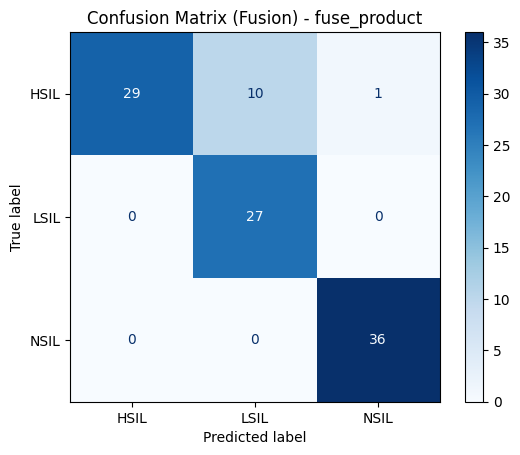

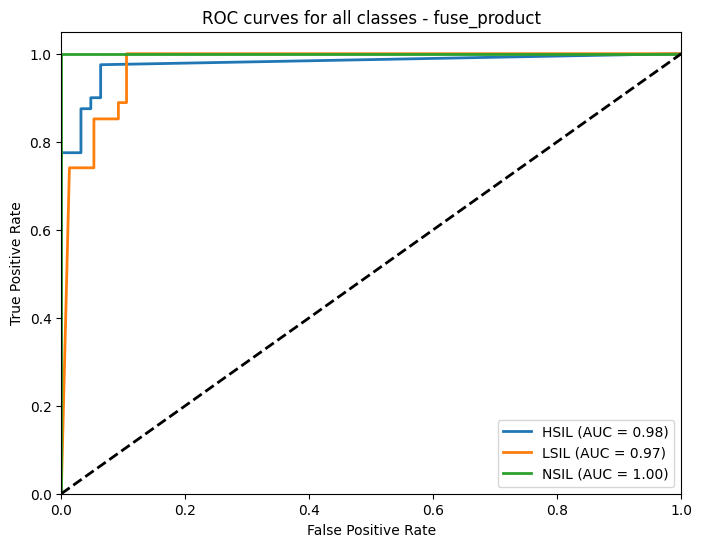

In [29]:
metrics_and_plots(fuse_product)

Accuracy : 0.8835
Precision: 0.8886
Recall   : 0.8960
F1-score : 0.8808


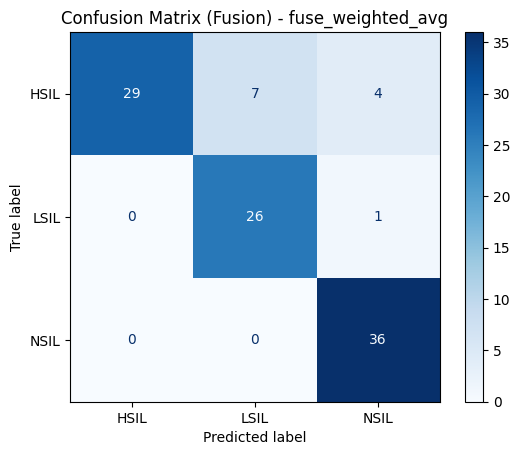

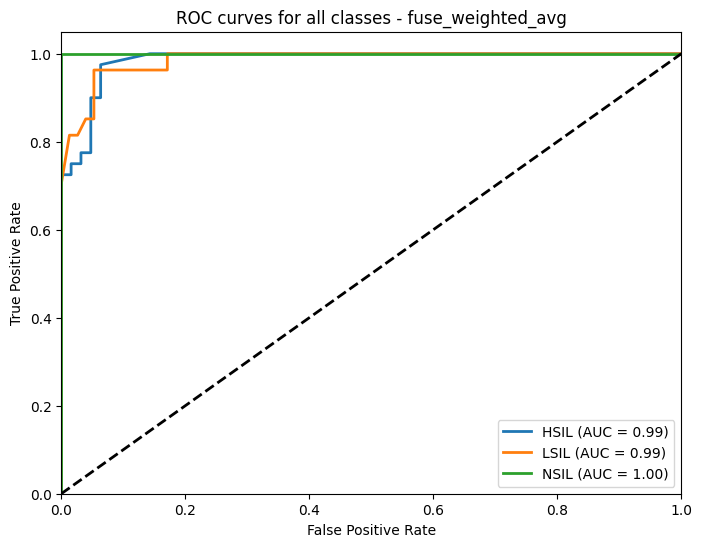

In [30]:
metrics_and_plots(fuse_weighted_avg)

Accuracy : 0.8932
Precision: 0.9009
Recall   : 0.9083
F1-score : 0.8902


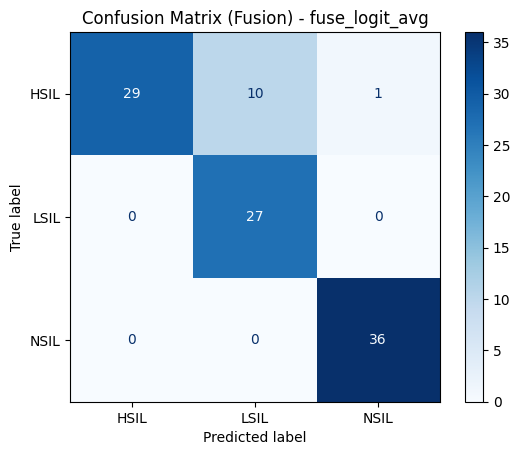

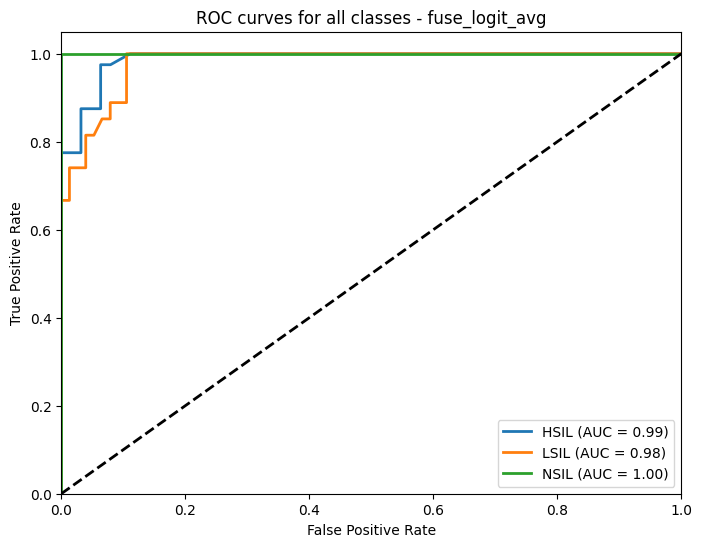

In [31]:
metrics_and_plots(fuse_logit_avg)

Accuracy : 0.8835
Precision: 0.8899
Recall   : 0.8960
F1-score : 0.8817


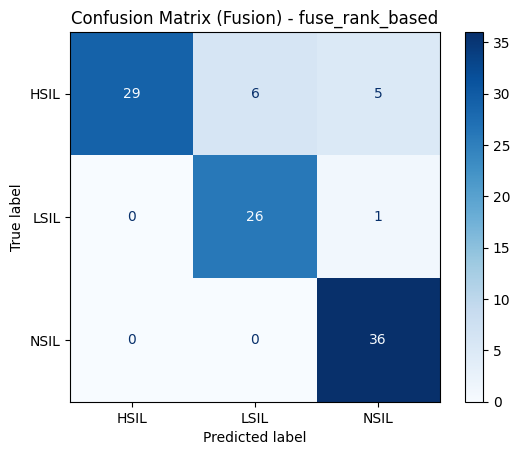

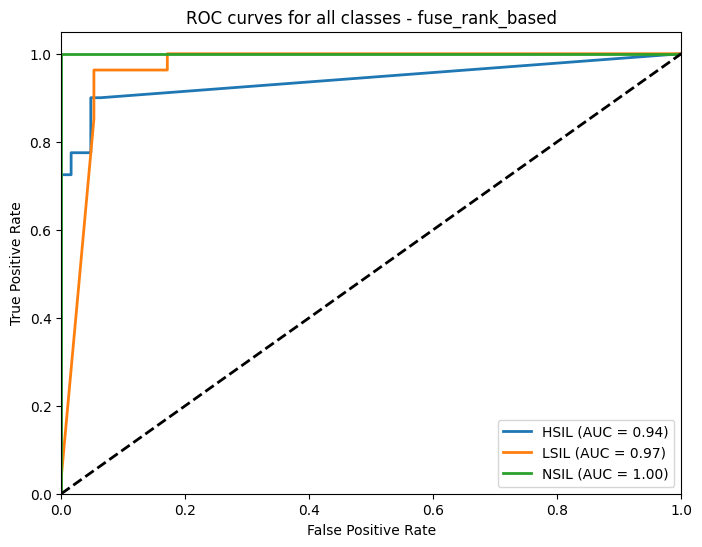

In [32]:
metrics_and_plots(fuse_rank_based)

Accuracy : 0.8835
Precision: 0.8886
Recall   : 0.8960
F1-score : 0.8808


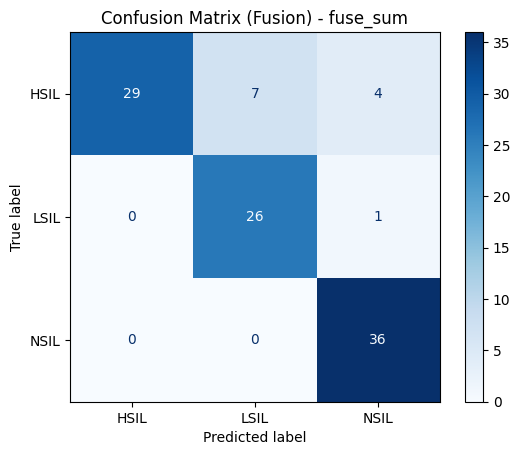

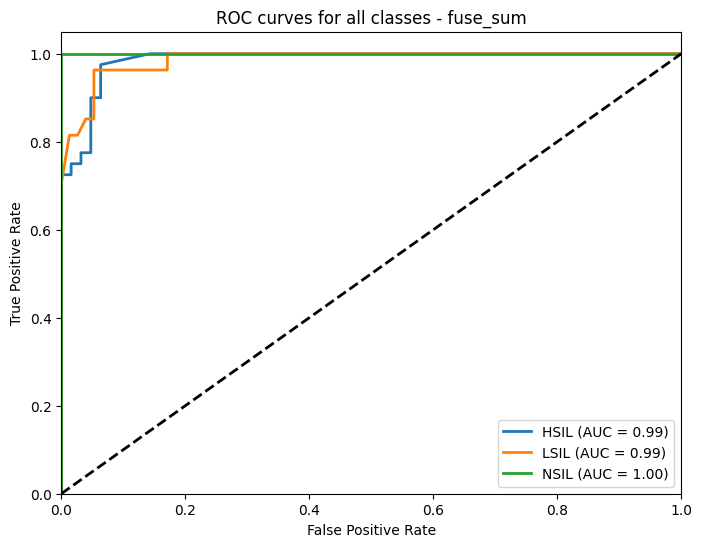

In [33]:
metrics_and_plots(fuse_sum)

Accuracy : 0.8835
Precision: 0.8899
Recall   : 0.8960
F1-score : 0.8817


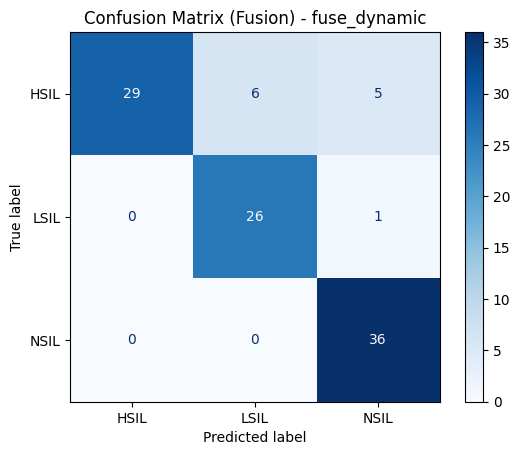

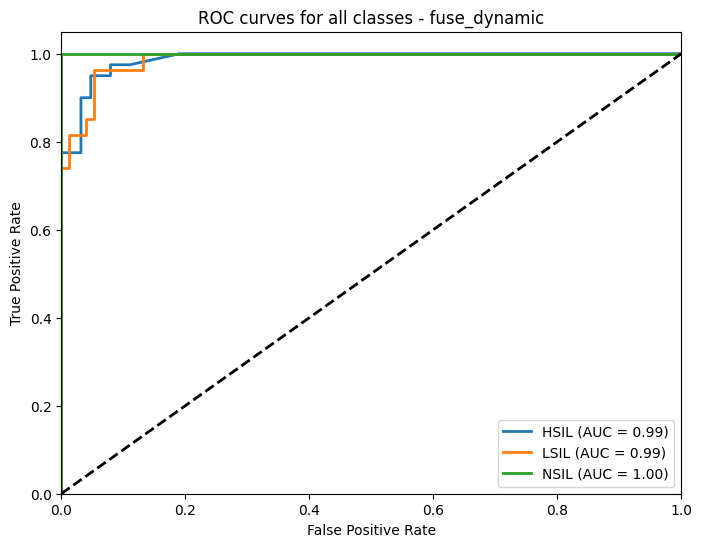

In [34]:
metrics_and_plots(fuse_dynamic)